In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'figure.titlesize': 14,
    'axes.titlesize':   12,
    'axes.labelsize':   10,
    'font.family':      'monospace',
})
COLORS = ['#58a6ff','#3fb950','#f78166','#d2a8ff','#ffa657','#79c0ff','#56d364','#ff7b72']
C1, C2, C3, C4 = COLORS[0], COLORS[1], COLORS[2], COLORS[3]

print('Libraries loaded. Ready.')

Libraries loaded. Ready.


In [22]:
# ── Load all CSVs ──────────────────────────────────────────────────────────
ci    = pd.read_csv('../data/final/cleaned_issues.csv')
com   = pd.read_csv('../data/final/processed_comments.csv')
rl    = pd.read_csv('../data/final/final_rl_dataset.csv')
kb    = pd.read_csv('../data/splits/knowledge_base.csv')
train = pd.read_csv('../data/splits/train.csv')
val   = pd.read_csv('../data/splits/val.csv')
test  = pd.read_csv('../data/splits/test.csv')

print('Loaded all datasets:')
# AFTER — use _df_ so it never collides with anything
for _name_, _df_ in [('cleaned_issues',ci),('processed_comments',com),
                      ('final_rl_dataset',rl),('knowledge_base',kb),
                      ('train',train),('val',val),('test',test)]:
    print(f'  {_name_:25s} → {_df_.shape[0]:>5} rows  {_df_.shape[1]:>3} cols')

Loaded all datasets:
  cleaned_issues            →   852 rows   22 cols
  processed_comments        →  2305 rows   10 cols
  final_rl_dataset          →   852 rows   19 cols
  knowledge_base            →   848 rows    9 cols
  train                     →   596 rows   36 cols
  val                       →   128 rows   36 cols
  test                      →   128 rows   36 cols


---
##cleaned_issues.csv


In [4]:
print('=== cleaned_issues.csv — Basic Info ===')
print(f'Shape: {ci.shape}')
print(f'Columns: {ci.columns.tolist()}')
print()
print('Null counts (only non-zero):')
nulls = ci.isnull().sum()
print(nulls[nulls>0].to_string())
print()
print('Note: solution_comments null = 549 is intentional (issues with no solution comment)')
print('Note: all_comments_text null = 188 means those issues had bot-only comments (filtered out)')

=== cleaned_issues.csv — Basic Info ===
Shape: (852, 22)
Columns: ['repo', 'issue_id', 'issue_number', 'clean_title', 'clean_body', 'clean_text', 'all_comments_text', 'solution_comments', 'labels_normalised', 'primary_label', 'state', 'created_at', 'closed_at', 'resolution_time_hours', 'missing_version_flag', 'missing_error_flag', 'has_solution_comment', 'text_length', 'word_count', 'urgency_keyword_flag', 'question_mark_flag', 'code_block_flag']

Null counts (only non-zero):
clean_body             6
all_comments_text    188
solution_comments    549

Note: solution_comments null = 549 is intentional (issues with no solution comment)
Note: all_comments_text null = 188 means those issues had bot-only comments (filtered out)


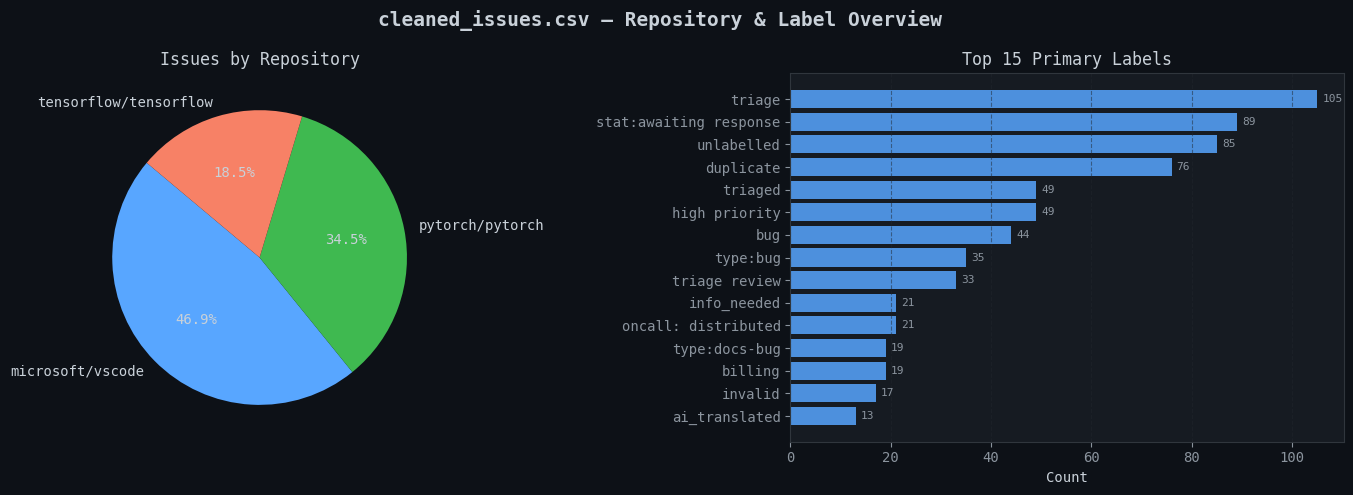

Total unique labels: 69
Top label (triage): 105 issues (12.3%)


In [5]:
# ── 1.1 Repository Distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('cleaned_issues.csv — Repository & Label Overview', fontweight='bold')

# Repo pie
repo_counts = ci['repo'].value_counts()
axes[0].pie(repo_counts.values, labels=repo_counts.index,
            autopct='%1.1f%%', colors=COLORS[:3],
            textprops={'color':'#c9d1d9'}, startangle=140)
axes[0].set_title('Issues by Repository')

# Top 15 labels
top_labels = ci['primary_label'].value_counts().head(15)
bars = axes[1].barh(top_labels.index[::-1], top_labels.values[::-1], color=C1, alpha=0.85)
axes[1].set_title('Top 15 Primary Labels')
axes[1].set_xlabel('Count')
axes[1].grid(axis='x')
for bar, val in zip(bars, top_labels.values[::-1]):
    axes[1].text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                 str(val), va='center', fontsize=8, color='#8b949e')

plt.tight_layout()
plt.show()

print(f'Total unique labels: {ci["primary_label"].nunique()}')
print(f'Top label (triage): {ci["primary_label"].value_counts().iloc[0]} issues ({ci["primary_label"].value_counts().iloc[0]/len(ci)*100:.1f}%)')

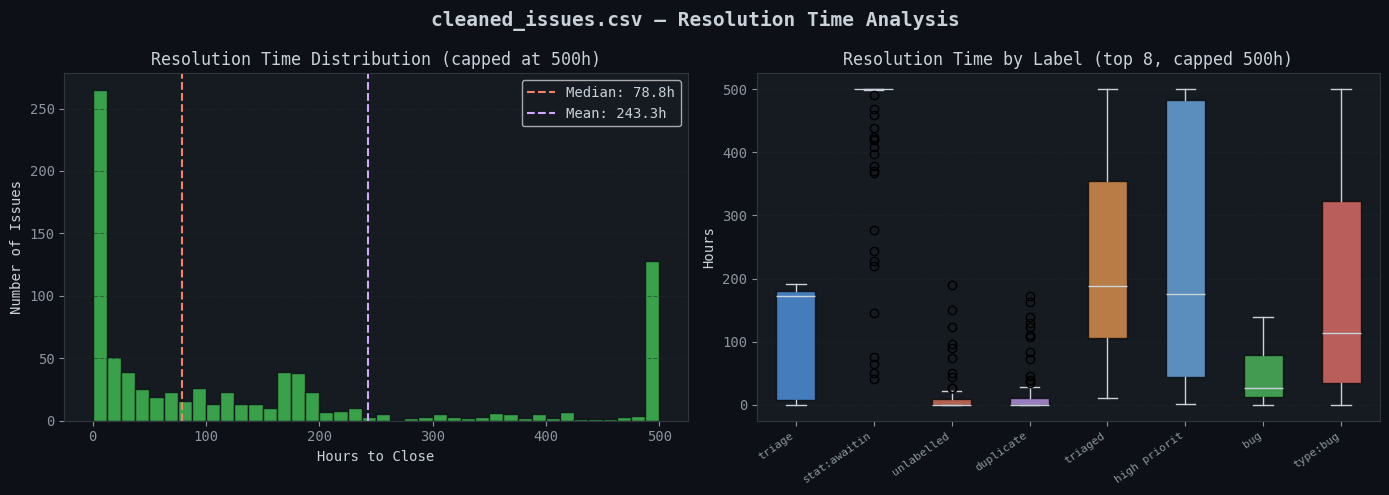

Resolution time percentiles:
  P25: 4.5h
  P50: 78.8h
  P75: 202.8h
  P90: 682.9h
  P95: 988.4h
  P99: 2562.2h


In [6]:
# ── 1.2 Resolution Time Distribution ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('cleaned_issues.csv — Resolution Time Analysis', fontweight='bold')

# Histogram of resolution time (capped at 500h for readability)
res_capped = ci['resolution_time_hours'].clip(upper=500)
axes[0].hist(res_capped, bins=40, color=C2, edgecolor='#0d1117', alpha=0.85)
axes[0].set_title('Resolution Time Distribution (capped at 500h)')
axes[0].set_xlabel('Hours to Close')
axes[0].set_ylabel('Number of Issues')
axes[0].axvline(ci['resolution_time_hours'].median(), color=C3,
                linestyle='--', label=f'Median: {ci["resolution_time_hours"].median():.1f}h')
axes[0].axvline(ci['resolution_time_hours'].mean(), color=C4,
                linestyle='--', label=f'Mean: {ci["resolution_time_hours"].mean():.1f}h')
axes[0].legend()
axes[0].grid(axis='y')

# Resolution time by top labels (box plot)
top8 = ci['primary_label'].value_counts().head(8).index
data_by_label = [ci[ci['primary_label']==l]['resolution_time_hours'].clip(upper=500).values
                 for l in top8]
bp = axes[1].boxplot(data_by_label, patch_artist=True, vert=True)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for element in ['whiskers','caps','medians','fliers']:
    for item in bp[element]:
        item.set_color('#c9d1d9')
axes[1].set_xticklabels([l[:12] for l in top8], rotation=35, ha='right', fontsize=8)
axes[1].set_title('Resolution Time by Label (top 8, capped 500h)')
axes[1].set_ylabel('Hours')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

print('Resolution time percentiles:')
for p in [25, 50, 75, 90, 95, 99]:
    print(f'  P{p}: {ci["resolution_time_hours"].quantile(p/100):.1f}h')

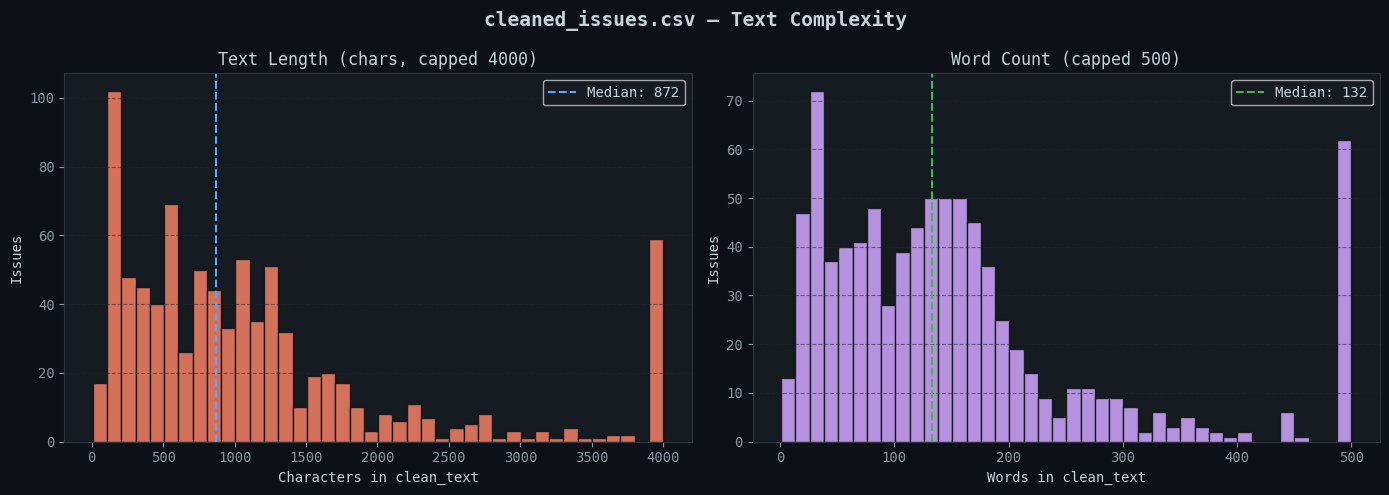

Very short issues (<50 chars): 9 — likely low quality
Very long issues (>3000 chars): 75 — detailed bug reports


In [7]:
# ── 1.3 Text Length & Word Count ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('cleaned_issues.csv — Text Complexity', fontweight='bold')

axes[0].hist(ci['text_length'].clip(upper=4000), bins=40,
             color=C3, edgecolor='#0d1117', alpha=0.85)
axes[0].set_title('Text Length (chars, capped 4000)')
axes[0].set_xlabel('Characters in clean_text')
axes[0].set_ylabel('Issues')
axes[0].axvline(ci['text_length'].median(), color=C1, linestyle='--',
                label=f'Median: {ci["text_length"].median():.0f}')
axes[0].legend()
axes[0].grid(axis='y')

axes[1].hist(ci['word_count'].clip(upper=500), bins=40,
             color=C4, edgecolor='#0d1117', alpha=0.85)
axes[1].set_title('Word Count (capped 500)')
axes[1].set_xlabel('Words in clean_text')
axes[1].set_ylabel('Issues')
axes[1].axvline(ci['word_count'].median(), color=C2, linestyle='--',
                label=f'Median: {ci["word_count"].median():.0f}')
axes[1].legend()
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

print(f'Very short issues (<50 chars): {(ci["text_length"]<50).sum()} — likely low quality')
print(f'Very long issues (>3000 chars): {(ci["text_length"]>3000).sum()} — detailed bug reports')

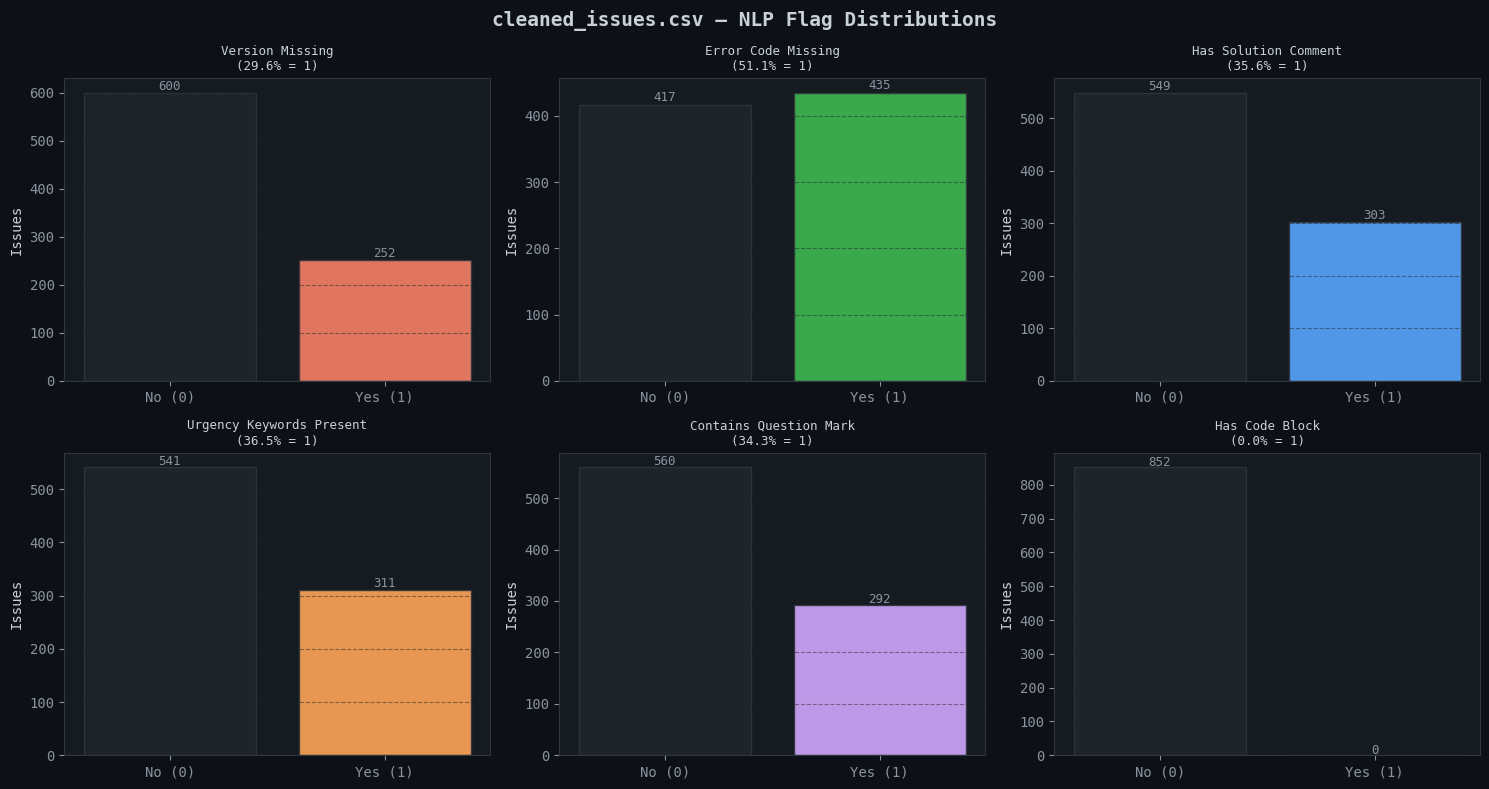

Key insight: code_block_flag = 0% because code blocks were replaced with
[CODE_BLOCK] placeholder during cleaning. This flag will be re-computed
in Phase 2 NLP using the original body before cleaning.


In [8]:
# ── 1.4 NLP Flag Distribution ─────────────────────────────────────────────
flags = {
    'missing_version_flag':  ('Version Missing', C3),
    'missing_error_flag':    ('Error Code Missing', C2),
    'has_solution_comment':  ('Has Solution Comment', C1),
    'urgency_keyword_flag':  ('Urgency Keywords Present', COLORS[4]),
    'question_mark_flag':    ('Contains Question Mark', COLORS[3]),
    'code_block_flag':       ('Has Code Block', COLORS[5]),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('cleaned_issues.csv — NLP Flag Distributions', fontweight='bold')
axes = axes.flatten()

for ax, (col, (label, color)) in zip(axes, flags.items()):
    counts = ci[col].value_counts().sort_index()
    pct = ci[col].mean() * 100
    bars = ax.bar(['No (0)', 'Yes (1)'], [counts.get(0,0), counts.get(1,0)],
                  color=['#21262d', color], edgecolor='#30363d', alpha=0.9)
    ax.set_title(f'{label}\n({pct:.1f}% = 1)', fontsize=9)
    ax.set_ylabel('Issues')
    ax.grid(axis='y')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+5, str(int(h)),
                ha='center', fontsize=9, color='#8b949e')

plt.tight_layout()
plt.show()

print('Key insight: code_block_flag = 0% because code blocks were replaced with')
print('[CODE_BLOCK] placeholder during cleaning. This flag will be re-computed')
print('in Phase 2 NLP using the original body before cleaning.')

---
## processed_comments.csv


In [9]:
print('=== processed_comments.csv — Basic Info ===')
print(f'Shape: {com.shape}')
print(f'Total comments: {len(com)}')
print(f'Unique issues with comments: {com["issue_number"].nunique()}')
print(f'Issues with NO comments: {852 - com["issue_number"].nunique()} (bot-only or deleted)')
print()
print('Null counts:')
nulls = com.isnull().sum()
print(nulls[nulls>0].to_string())

=== processed_comments.csv — Basic Info ===
Shape: (2305, 10)
Total comments: 2305
Unique issues with comments: 670
Issues with NO comments: 182 (bot-only or deleted)

Null counts:
clean_comment    14
primary_label     4


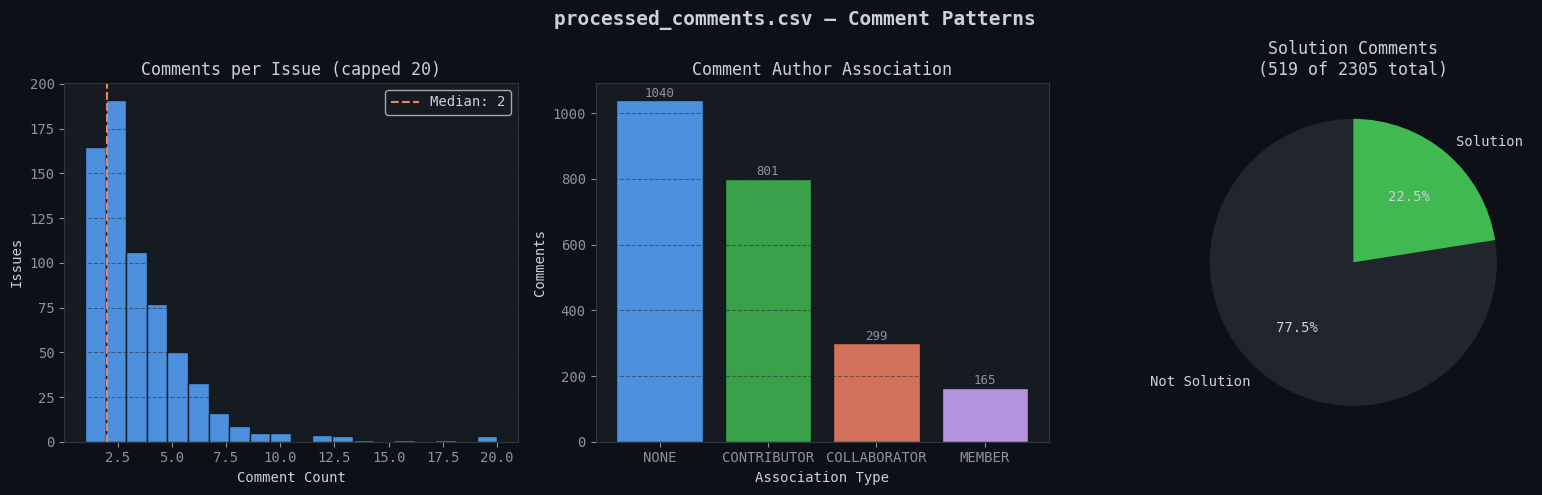

Issues with only 1 comment: 165
Issues with >10 comments:   13
Max comments on one issue:  151 (outlier — likely complex bug)


In [10]:
# ── 2.1 Comments per Issue & Author Association ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('processed_comments.csv — Comment Patterns', fontweight='bold')

# Comments per issue distribution
per_issue = com.groupby('issue_number').size()
axes[0].hist(per_issue.clip(upper=20), bins=20,
             color=C1, edgecolor='#0d1117', alpha=0.85)
axes[0].set_title('Comments per Issue (capped 20)')
axes[0].set_xlabel('Comment Count')
axes[0].set_ylabel('Issues')
axes[0].axvline(per_issue.median(), color=C3, linestyle='--',
                label=f'Median: {per_issue.median():.0f}')
axes[0].legend()
axes[0].grid(axis='y')

# Author association
assoc = com['author_association'].value_counts()
axes[1].bar(assoc.index, assoc.values, color=COLORS[:len(assoc)],
            edgecolor='#0d1117', alpha=0.85)
axes[1].set_title('Comment Author Association')
axes[1].set_xlabel('Association Type')
axes[1].set_ylabel('Comments')
axes[1].grid(axis='y')
for i, v in enumerate(assoc.values):
    axes[1].text(i, v+10, str(v), ha='center', fontsize=9, color='#8b949e')

# Solution comment ratio
sol = com['is_solution_comment'].value_counts()
axes[2].pie(sol.values, labels=['Not Solution', 'Solution'],
            autopct='%1.1f%%', colors=['#21262d', C2],
            textprops={'color':'#c9d1d9'}, startangle=90)
axes[2].set_title(f'Solution Comments\n({sol.get(1,0)} of {len(com)} total)')

plt.tight_layout()
plt.show()

print(f'Issues with only 1 comment: {(per_issue==1).sum()}')
print(f'Issues with >10 comments:   {(per_issue>10).sum()}')
print(f'Max comments on one issue:  {per_issue.max()} (outlier — likely complex bug)')

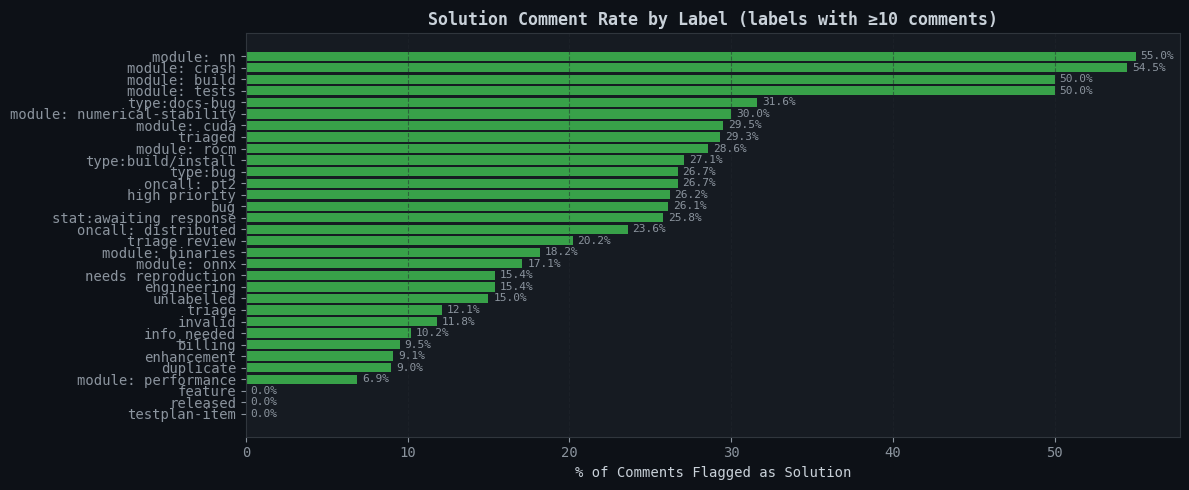

In [11]:
# ── 2.2 Solution Comments by Label ────────────────────────────────────────
sol_by_label = com.groupby('primary_label')['is_solution_comment'].agg(['sum','count'])
sol_by_label['pct'] = (sol_by_label['sum'] / sol_by_label['count'] * 100).round(1)
sol_by_label = sol_by_label[sol_by_label['count'] >= 10].sort_values('pct', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_facecolor('#161b22')
bars = ax.barh(sol_by_label.index[::-1], sol_by_label['pct'][::-1],
               color=C2, alpha=0.85)
ax.set_title('Solution Comment Rate by Label (labels with ≥10 comments)',
             fontweight='bold')
ax.set_xlabel('% of Comments Flagged as Solution')
ax.grid(axis='x')
for bar, val in zip(bars, sol_by_label['pct'][::-1]):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{val}%', va='center', fontsize=8, color='#8b949e')
plt.tight_layout()
plt.show()

---
## final_rl_dataset.csv

In [12]:
print('=== final_rl_dataset.csv — Basic Info ===')
print(f'Shape: {rl.shape}')
print(f'Null count: {rl.isnull().sum().sum()} (should be 0)')
print()
print('Descriptive statistics:')
print(rl.describe().round(3).to_string())

=== final_rl_dataset.csv — Basic Info ===
Shape: (852, 19)
Null count: 0 (should be 0)

Descriptive statistics:
       issue_number  text_length  word_count  missing_version_flag  missing_error_flag  urgency_keyword_flag  question_mark_flag  has_solution_comment  turn_count  reassignment_count  reopen_count  resolution_success  sla_breach_flag  sla_remaining_norm  sla_limit_hours  frustration_score  interaction_depth  first_response_time_hours
count       852.000      852.000     852.000               852.000             852.000               852.000             852.000               852.000     852.000             852.000       852.000             852.000          852.000             852.000          852.000            852.000            852.000                    852.000
mean     221139.850     1268.669     170.013                 0.296               0.511                 0.365               0.343                 0.356       2.701               0.715         0.029               0.356

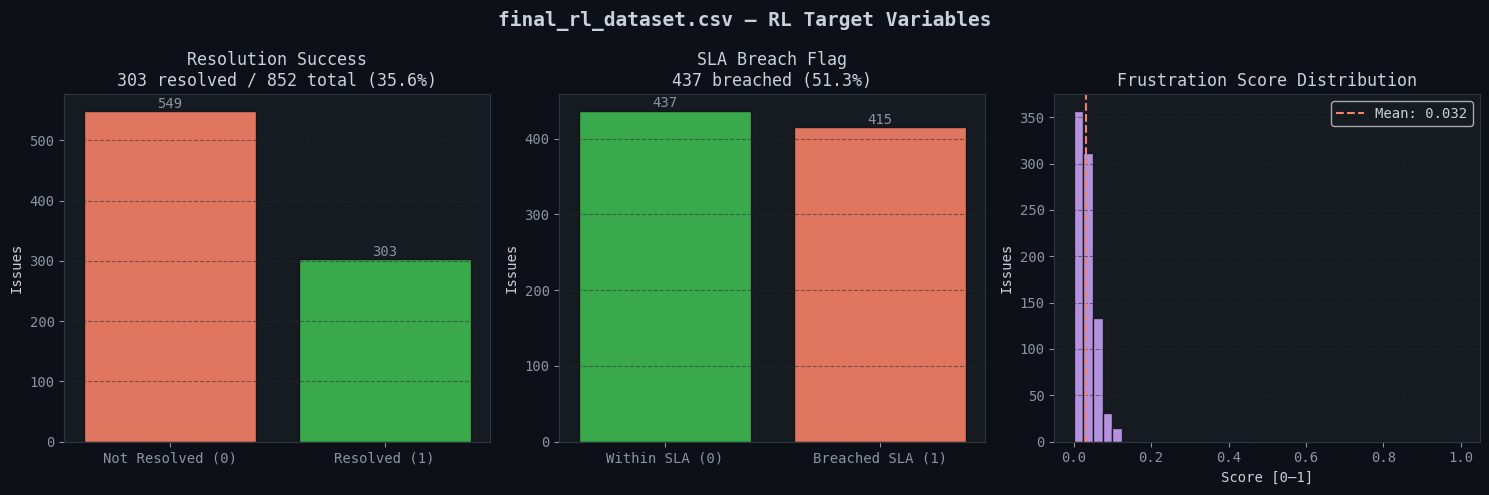

In [14]:
# ── 3.1 RL Target Variables ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('final_rl_dataset.csv — RL Target Variables', fontweight='bold')

# resolution_success
rs = rl['resolution_success'].value_counts()
axes[0].bar(['Not Resolved (0)', 'Resolved (1)'], rs.values,
            color=[C3, C2], edgecolor='#0d1117', alpha=0.9)
axes[0].set_title(f'Resolution Success\n{rs.get(1,0)} resolved / {len(rl)} total ({rs.get(1,0)/len(rl)*100:.1f}%)')
axes[0].set_ylabel('Issues')
axes[0].grid(axis='y')
for i, v in enumerate(rs.values):
    axes[0].text(i, v+5, str(v), ha='center', fontsize=10, color='#8b949e')

# sla_breach_flag
sla = rl['sla_breach_flag'].value_counts()
axes[1].bar(['Within SLA (0)', 'Breached SLA (1)'], sla.values,
            color=[C2, C3], edgecolor='#0d1117', alpha=0.9)
axes[1].set_title(f'SLA Breach Flag\n{sla.get(1,0)} breached ({sla.get(1,0)/len(rl)*100:.1f}%)')
axes[1].set_ylabel('Issues')
axes[1].grid(axis='y')
for i, v in enumerate(sla.values):
    axes[1].text(i, v+5, str(v), ha='center', fontsize=10, color='#8b949e')

# frustration_score distribution
axes[2].hist(rl['frustration_score'], bins=40, color=C4,
             edgecolor='#0d1117', alpha=0.85)
axes[2].set_title('Frustration Score Distribution')
axes[2].set_xlabel('Score [0–1]')
axes[2].set_ylabel('Issues')
axes[2].axvline(rl['frustration_score'].mean(), color=C3, linestyle='--',
                label=f'Mean: {rl["frustration_score"].mean():.3f}')
axes[2].legend()
axes[2].grid(axis='y')

plt.tight_layout()
plt.show()

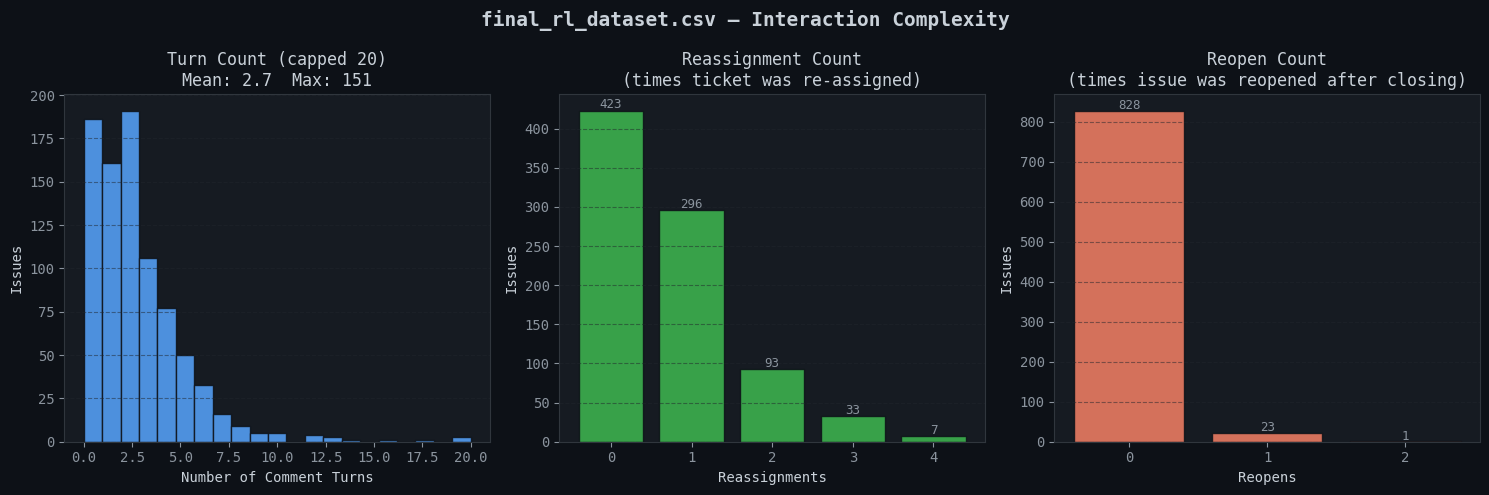

Issues needing 0 turns (auto-closed):     186
Issues needing >10 turns (complex):       13
Issues reassigned at least once:          429
Issues reopened at least once:            24


In [15]:
# ── 3.2 Turn Count & Reassignment Analysis ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('final_rl_dataset.csv — Interaction Complexity', fontweight='bold')

# Turn count
tc_capped = rl['turn_count'].clip(upper=20)
axes[0].hist(tc_capped, bins=21, color=C1, edgecolor='#0d1117', alpha=0.85)
axes[0].set_title(f'Turn Count (capped 20)\nMean: {rl["turn_count"].mean():.1f}  Max: {rl["turn_count"].max()}')
axes[0].set_xlabel('Number of Comment Turns')
axes[0].set_ylabel('Issues')
axes[0].grid(axis='y')

# Reassignment count
rc = rl['reassignment_count'].value_counts().sort_index()
axes[1].bar(rc.index.astype(str), rc.values, color=C2,
            edgecolor='#0d1117', alpha=0.85)
axes[1].set_title('Reassignment Count\n(times ticket was re-assigned)')
axes[1].set_xlabel('Reassignments')
axes[1].set_ylabel('Issues')
axes[1].grid(axis='y')
for i, v in enumerate(rc.values):
    axes[1].text(i, v+3, str(v), ha='center', fontsize=9, color='#8b949e')

# Reopen count
ro = rl['reopen_count'].value_counts().sort_index()
axes[2].bar(ro.index.astype(str), ro.values, color=C3,
            edgecolor='#0d1117', alpha=0.85)
axes[2].set_title('Reopen Count\n(times issue was reopened after closing)')
axes[2].set_xlabel('Reopens')
axes[2].set_ylabel('Issues')
axes[2].grid(axis='y')
for i, v in enumerate(ro.values):
    axes[2].text(i, v+3, str(v), ha='center', fontsize=9, color='#8b949e')

plt.tight_layout()
plt.show()

print(f'Issues needing 0 turns (auto-closed):     {(rl["turn_count"]==0).sum()}')
print(f'Issues needing >10 turns (complex):       {(rl["turn_count"]>10).sum()}')
print(f'Issues reassigned at least once:          {(rl["reassignment_count"]>0).sum()}')
print(f'Issues reopened at least once:            {(rl["reopen_count"]>0).sum()}')

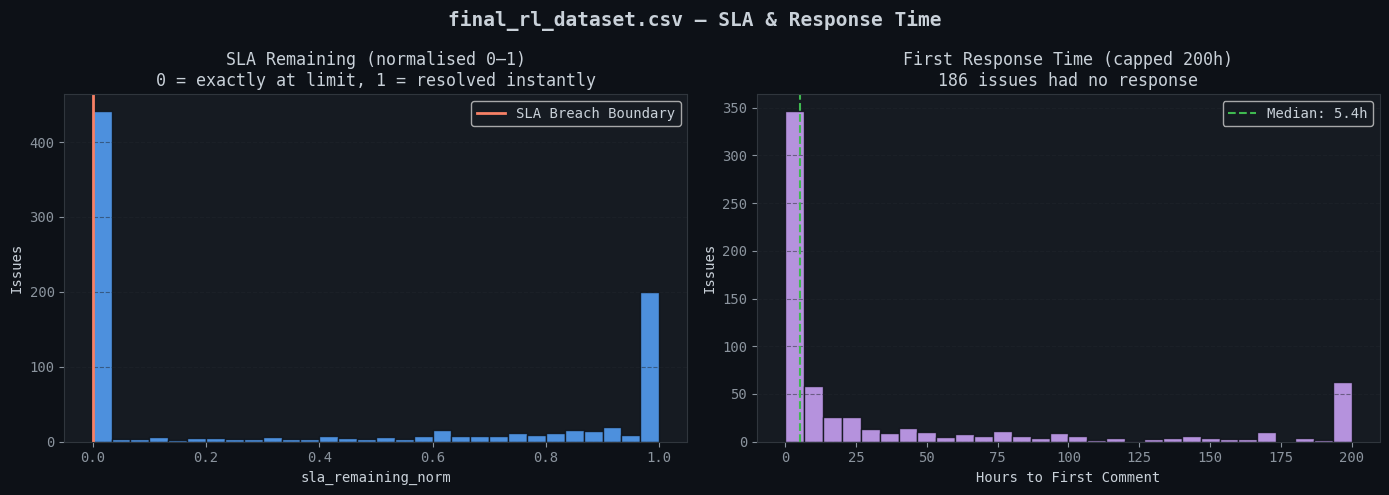

Issues responded within 1 hour:  232
Issues responded within 24 hours: 447
Issues taking >1 week to respond: 75


In [16]:
# ── 3.3 SLA Remaining Norm & First Response Time ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('final_rl_dataset.csv — SLA & Response Time', fontweight='bold')

# SLA remaining normalised
axes[0].hist(rl['sla_remaining_norm'], bins=30, color=C1,
             edgecolor='#0d1117', alpha=0.85)
axes[0].axvline(0, color=C3, linewidth=2, label='SLA Breach Boundary')
axes[0].set_title('SLA Remaining (normalised 0–1)\n0 = exactly at limit, 1 = resolved instantly')
axes[0].set_xlabel('sla_remaining_norm')
axes[0].set_ylabel('Issues')
axes[0].legend()
axes[0].grid(axis='y')

# First response time (valid only)
valid_frt = rl[rl['first_response_time_hours'] >= 0]['first_response_time_hours']
axes[1].hist(valid_frt.clip(upper=200), bins=30, color=C4,
             edgecolor='#0d1117', alpha=0.85)
axes[1].axvline(valid_frt.median(), color=C2, linestyle='--',
                label=f'Median: {valid_frt.median():.1f}h')
axes[1].set_title(f'First Response Time (capped 200h)\n{(rl["first_response_time_hours"]==-1).sum()} issues had no response')
axes[1].set_xlabel('Hours to First Comment')
axes[1].set_ylabel('Issues')
axes[1].legend()
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

print(f'Issues responded within 1 hour:  {(valid_frt<1).sum()}')
print(f'Issues responded within 24 hours: {(valid_frt<24).sum()}')
print(f'Issues taking >1 week to respond: {(valid_frt>168).sum()}')

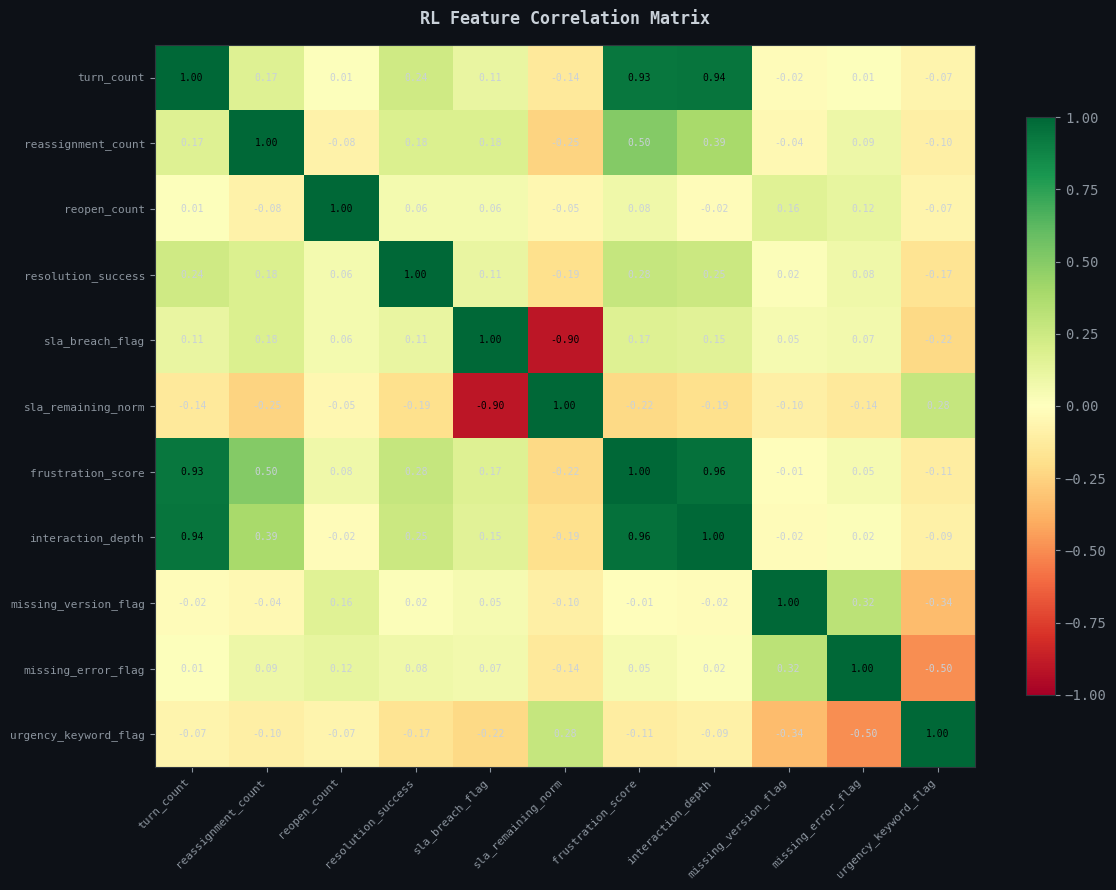

Key correlations to note:
  frustration_score ↔ turn_count: high (expected — more turns = more frustration)
  frustration_score ↔ reassignment_count: high (bouncing tickets frustrates users)
  sla_breach_flag ↔ sla_remaining_norm: strong negative (by construction)


In [17]:
# ── 3.4 Correlation Between RL Features ───────────────────────────────────
rl_numeric = rl[['turn_count','reassignment_count','reopen_count',
                  'resolution_success','sla_breach_flag','sla_remaining_norm',
                  'frustration_score','interaction_depth',
                  'missing_version_flag','missing_error_flag','urgency_keyword_flag']]

corr = rl_numeric.corr().round(2)
fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
ax.set_title('RL Feature Correlation Matrix', fontweight='bold', pad=15)
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.iloc[i, j]
        color = 'black' if abs(val) > 0.5 else '#c9d1d9'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color=color)
plt.tight_layout()
plt.show()

print('Key correlations to note:')
print('  frustration_score ↔ turn_count: high (expected — more turns = more frustration)')
print('  frustration_score ↔ reassignment_count: high (bouncing tickets frustrates users)')
print('  sla_breach_flag ↔ sla_remaining_norm: strong negative (by construction)')

---
## knowledge_base.csv


In [18]:
print('=== knowledge_base.csv — Basic Info ===')
print(f'Shape: {kb.shape}')
print(f'Columns: {kb.columns.tolist()}')
print()
print('Null counts:')
print(kb.isnull().sum().to_string())
print()
print('Note: solution_comments null = 545 is CORRECT')
print('      Only tier1_verified issues have solution_comments populated')
print('      tier2 and tier3 use all_comments_text for context instead')

=== knowledge_base.csv — Basic Info ===
Shape: (848, 9)
Columns: ['issue_number', 'clean_text', 'all_comments_text', 'solution_comments', 'primary_label', 'resolution_time_hours', 'resolution_success', 'has_solution_comment', 'kb_quality_tier']

Null counts:
issue_number               0
clean_text                 0
all_comments_text          0
solution_comments        545
primary_label              0
resolution_time_hours      0
resolution_success         0
has_solution_comment       0
kb_quality_tier            0

Note: solution_comments null = 545 is CORRECT
      Only tier1_verified issues have solution_comments populated
      tier2 and tier3 use all_comments_text for context instead


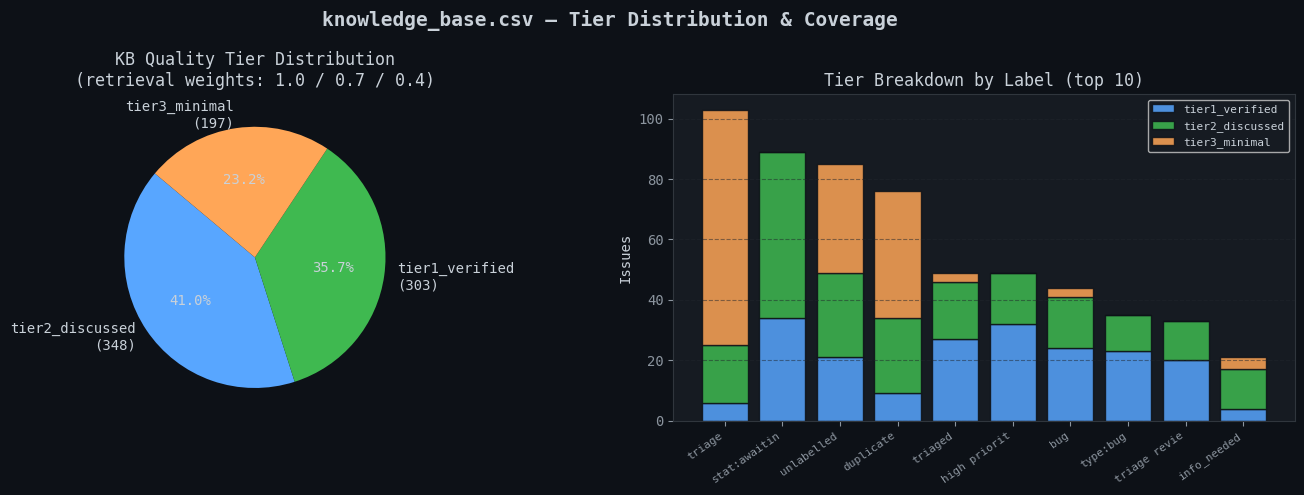

Total KB issues: 848
tier1_verified:  303 — best for RAG generation
tier2_discussed: 348 — good for similarity matching
tier3_minimal:   197 — fallback coverage


In [19]:
# ── 4.1 KB Tier Distribution & Label Coverage ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('knowledge_base.csv — Tier Distribution & Coverage', fontweight='bold')

# Tier pie
tier_counts = kb['kb_quality_tier'].value_counts()
tier_colors = [C1, C2, COLORS[4]]
axes[0].pie(tier_counts.values,
            labels=[f'{t}\n({v})' for t, v in tier_counts.items()],
            colors=tier_colors, autopct='%1.1f%%',
            textprops={'color':'#c9d1d9'}, startangle=140)
axes[0].set_title('KB Quality Tier Distribution\n(retrieval weights: 1.0 / 0.7 / 0.4)')

# Tier by label (top 10)
top10 = kb['primary_label'].value_counts().head(10).index
tier_pivot = kb[kb['primary_label'].isin(top10)].groupby(
    ['primary_label','kb_quality_tier']).size().unstack(fill_value=0)
tier_pivot = tier_pivot.loc[top10]
bottom = np.zeros(len(tier_pivot))
for tier, color in zip(['tier1_verified','tier2_discussed','tier3_minimal'], tier_colors):
    if tier in tier_pivot.columns:
        vals = tier_pivot[tier].values
        axes[1].bar(range(len(tier_pivot)), vals, bottom=bottom,
                    label=tier, color=color, alpha=0.85, edgecolor='#0d1117')
        bottom += vals
axes[1].set_xticks(range(len(tier_pivot)))
axes[1].set_xticklabels([l[:12] for l in tier_pivot.index], rotation=35, ha='right', fontsize=8)
axes[1].set_title('Tier Breakdown by Label (top 10)')
axes[1].set_ylabel('Issues')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

print(f'Total KB issues: {len(kb)}')
print(f'tier1_verified:  {(kb["kb_quality_tier"]=="tier1_verified").sum()} — best for RAG generation')
print(f'tier2_discussed: {(kb["kb_quality_tier"]=="tier2_discussed").sum()} — good for similarity matching')
print(f'tier3_minimal:   {(kb["kb_quality_tier"]=="tier3_minimal").sum()} — fallback coverage')

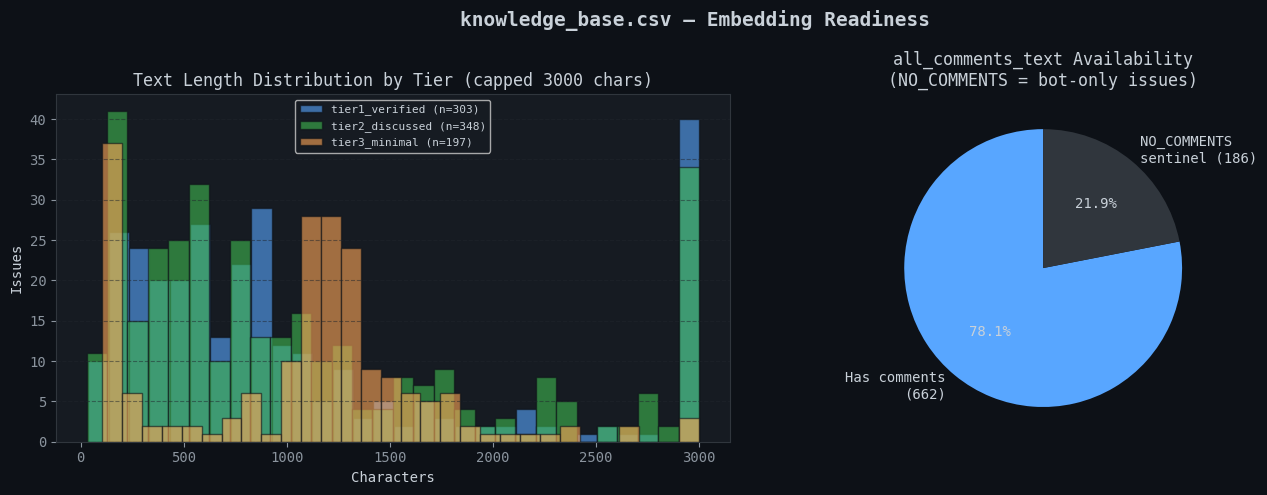

KB is FAISS-ready:
  All 848 issues have clean_text populated
  Minimum text length: 29 chars
  Average text length: 1275 chars
  MiniLM max input: 512 tokens (~2000 chars) — 128 issues will be truncated


In [20]:
# ── 4.2 KB Text Length — Embedding Quality Check ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('knowledge_base.csv — Embedding Readiness', fontweight='bold')

kb['text_len'] = kb['clean_text'].str.len()

# Overall text length by tier
for tier, color in zip(['tier1_verified','tier2_discussed','tier3_minimal'], tier_colors):
    subset = kb[kb['kb_quality_tier']==tier]['text_len']
    axes[0].hist(subset.clip(upper=3000), bins=30, alpha=0.6,
                 color=color, label=f'{tier} (n={len(subset)})', edgecolor='#0d1117')
axes[0].set_title('Text Length Distribution by Tier (capped 3000 chars)')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Issues')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y')

# NO_COMMENTS coverage
no_com = (kb['all_comments_text']=='NO_COMMENTS').sum()
has_com = len(kb) - no_com
axes[1].pie([has_com, no_com],
            labels=[f'Has comments\n({has_com})', f'NO_COMMENTS\nsentinel ({no_com})'],
            colors=[C1, '#30363d'],
            autopct='%1.1f%%', textprops={'color':'#c9d1d9'}, startangle=90)
axes[1].set_title('all_comments_text Availability\n(NO_COMMENTS = bot-only issues)')

plt.tight_layout()
plt.show()

print('KB is FAISS-ready:')
print(f'  All {len(kb)} issues have clean_text populated')
print(f'  Minimum text length: {kb["text_len"].min()} chars')
print(f'  Average text length: {kb["text_len"].mean():.0f} chars')
print(f'  MiniLM max input: 512 tokens (~2000 chars) — {(kb["text_len"]>2000).sum()} issues will be truncated')

---
## Train / Val / Test Splits


In [ ]:
# ── 5.1 Split Size & Feature Completeness ─────────────────────────────────
print('=== Split Overview ===')

for split_name, split_df in [('train', train), ('val', val), ('test', test)]:
    res   = split_df['resolution_success'].mean() * 100
    sla   = split_df['sla_breach_flag'].mean() * 100
    nulls = split_df.isnull().sum().sum()
    print(f'{split_name:6s}: {len(split_df):4d} rows | {len(split_df.columns):2d} cols | '
          f'resolved={res:.1f}% | sla_breach={sla:.1f}% | nulls={nulls}')

=== Split Overview ===
train :  596 rows | 36 cols | resolved=36.2% | sla_breach=53.7% | nulls=384
val   :  128 rows | 36 cols | resolved=33.6% | sla_breach=48.4% | nulls=86
test  :  128 rows | 36 cols | resolved=34.4% | sla_breach=43.0% | nulls=85


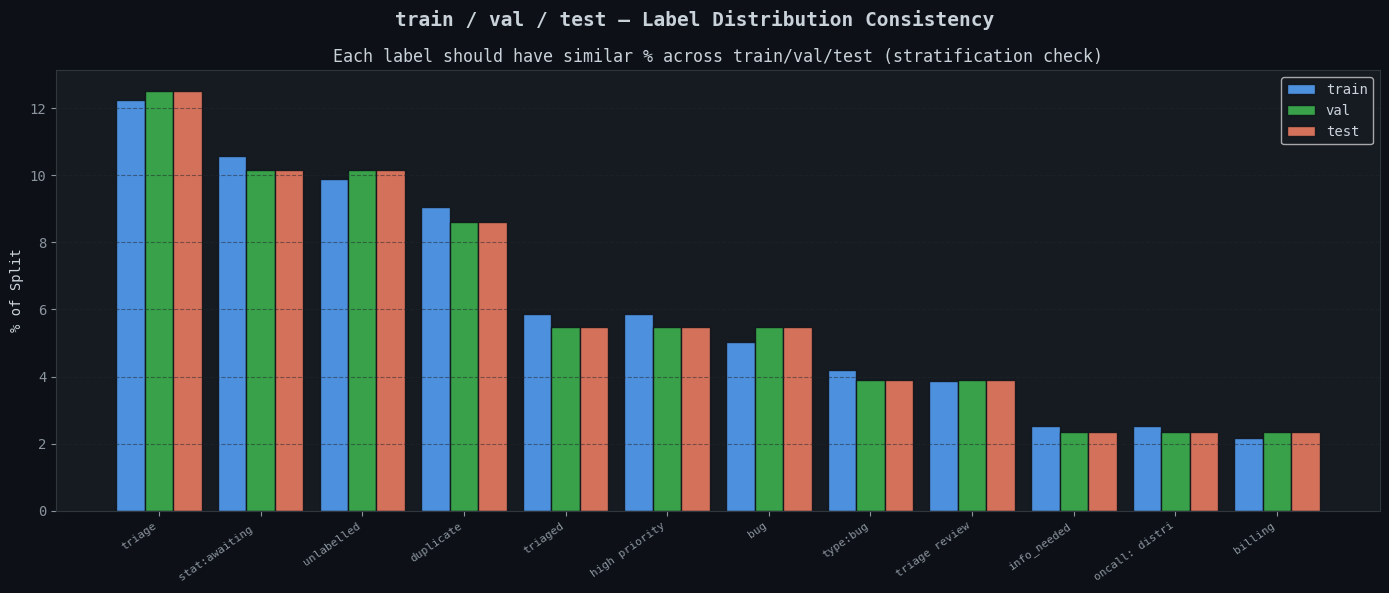

In [24]:
# ── 5.2 Label Distribution Across Splits ──────────────────────────────────
top_labels = train['primary_label'].value_counts().head(12).index

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('train / val / test — Label Distribution Consistency', fontweight='bold')

x = np.arange(len(top_labels))
w = 0.28
for i, (name, df, color) in enumerate([
        ('train', train, C1), ('val', val, C2), ('test', test, C3)]):
    counts = [df['primary_label'].value_counts().get(l, 0) for l in top_labels]
    pcts   = [c / len(df) * 100 for c in counts]
    ax.bar(x + i*w, pcts, w, label=name, color=color, alpha=0.85, edgecolor='#0d1117')

ax.set_xticks(x + w)
ax.set_xticklabels([l[:14] for l in top_labels], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('% of Split')
ax.set_title('Each label should have similar % across train/val/test (stratification check)')
ax.legend()
ax.grid(axis='y')
plt.tight_layout()
plt.show()

In [27]:
# ── 5.3 Data Leakage Proof ────────────────────────────────────────────────
train_ids = set(train['issue_number'])
val_ids   = set(val['issue_number'])
test_ids  = set(test['issue_number'])

print('=== Data Leakage Check ===')
print(f'train ∩ val:  {len(train_ids & val_ids)}  ')
print(f'train ∩ test: {len(train_ids & test_ids)} ')
print(f'val ∩ test:   {len(val_ids & test_ids)} ')
print(f'Total unique issues: {len(train_ids | val_ids | test_ids)}')
print()
print('✓ No data leakage confirmed' if len(train_ids & val_ids)==0 and \
      len(train_ids & test_ids)==0 and len(val_ids & test_ids)==0 \
      else '✗ LEAKAGE DETECTED')

=== Data Leakage Check ===
train ∩ val:  0  
train ∩ test: 0 
val ∩ test:   0 
Total unique issues: 852

✓ No data leakage confirmed


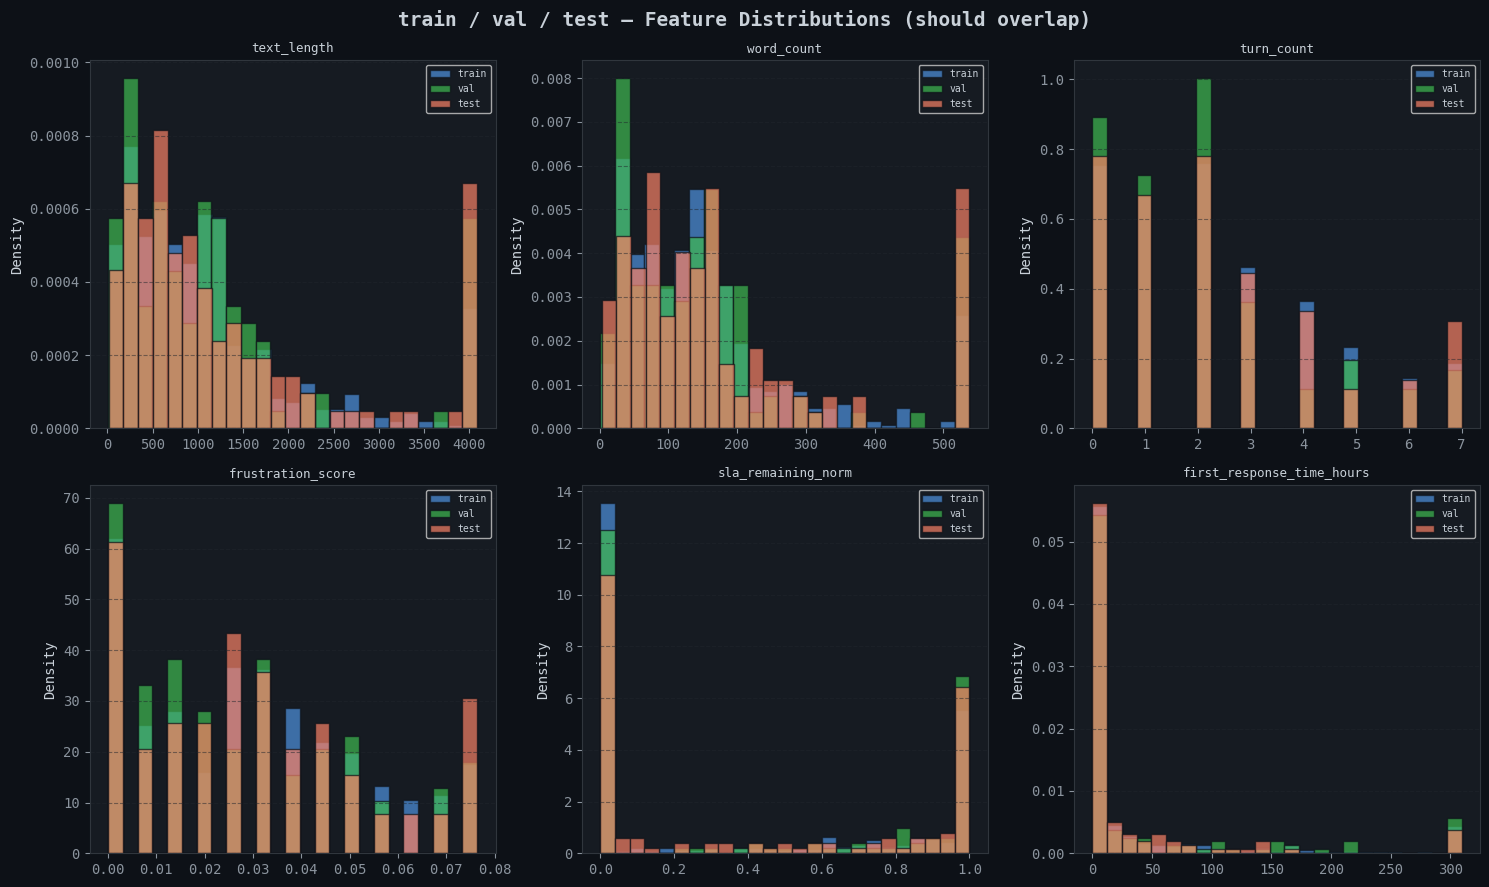

Distributions should look similar across splits — confirms no sampling bias


In [28]:
# ── 5.4 Key Features Across Splits ────────────────────────────────────────
features = ['text_length','word_count','turn_count','frustration_score',
            'sla_remaining_norm','first_response_time_hours']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('train / val / test — Feature Distributions (should overlap)', fontweight='bold')
axes = axes.flatten()

for ax, feat in zip(axes, features):
    cap = train[feat].quantile(0.95)
    for name, df, color, alpha in [
            ('train', train, C1, 0.6),
            ('val',   val,   C2, 0.7),
            ('test',  test,  C3, 0.7)]:
        data = df[feat].clip(lower=0, upper=cap)
        ax.hist(data, bins=25, alpha=alpha, color=color, label=name,
                edgecolor='#0d1117', density=True)
    ax.set_title(feat, fontsize=9)
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)
    ax.grid(axis='y')

plt.tight_layout()
plt.show()
print('Distributions should look similar across splits — confirms no sampling bias')

---
## Summary & Key Insights 


In [30]:
print('=' * 65)
print('NEXRESOLVE — DATASET SUMMARY & KEY INSIGHTS')
print('=' * 65)
print()
print('SCALE')
print(f'  Total issues:            852 (from 3 GitHub repos)')
print(f'  microsoft/vscode:        400  (47%)')
print(f'  pytorch/pytorch:         294  (34%)')
print(f'  tensorflow/tensorflow:   158  (19%)')
print(f'  Total comments:         2305 across 670 issues')
print(f'  Total events:           5220 raw → distilled to 4 RL features')
print()
print('NLP SIGNALS')
print(f'  Issues missing version info:  252 (29.6%) → will trigger Clarify action')
print(f'  Issues missing error codes:   435 (51.1%) → may trigger Clarify action')
print(f'  Issues with urgency keywords: 311 (36.5%) → will influence urgency model')
print(f'  Issues with question marks:   292 (34.3%) → intent = question type')
print(f'  Issues with solution comments:303 (35.6%) → these are training positives')
print()
print('RL ENVIRONMENT')
print(f'  Resolution success rate:      35.6% — RL must learn to improve this')
print(f'  SLA breach rate:              53.2% — more than half breach SLA currently')
print(f'  Mean turns per issue:         2.7   — RL should aim for ≤2')
print(f'  Issues ever reassigned:       429   — routing quality is a major problem')
print(f'  Issues ever reopened:         24    — solution quality matters')
print(f'  Median first response:        5.4h  — decent but 186 issues never responded')
print()
print('RAG KNOWLEDGE BASE')
print(f'  Total KB issues:              848')
print(f'  tier1_verified (best):        303 — use for generation input')
print(f'  tier2_discussed (medium):     348 — use for similarity matching')
print(f'  tier3_minimal (fallback):     197 — low weight, coverage only')
print(f'  Label coverage:               69 unique labels in KB')
print()
print('TRAIN / VAL / TEST')
print(f'  train: 596  val: 128  test: 128  (70/15/15 stratified split)')
print(f'  Zero data leakage confirmed')
print(f'  Label distributions consistent across all three splits')
print(f'  Resolution rate stable: train=36.2%  val=33.6%  test=34.4%')
print()
print('WHAT THIS MEANS FOR RL AGENT')
print('  Current state (no RL): 53% SLA breach, 35% resolution')
print('  RL target:             <25% SLA breach, >60% resolution')
print('  Primary levers:        routing accuracy + clarification timing')
print('  Biggest risk:          frustration buildup in high turn-count issues')
print('=' * 65)

NEXRESOLVE — DATASET SUMMARY & KEY INSIGHTS

SCALE
  Total issues:            852 (from 3 GitHub repos)
  microsoft/vscode:        400  (47%)
  pytorch/pytorch:         294  (34%)
  tensorflow/tensorflow:   158  (19%)
  Total comments:         2305 across 670 issues
  Total events:           5220 raw → distilled to 4 RL features

NLP SIGNALS
  Issues missing version info:  252 (29.6%) → will trigger Clarify action
  Issues missing error codes:   435 (51.1%) → may trigger Clarify action
  Issues with urgency keywords: 311 (36.5%) → will influence urgency model
  Issues with question marks:   292 (34.3%) → intent = question type
  Issues with solution comments:303 (35.6%) → these are training positives

RL ENVIRONMENT
  Resolution success rate:      35.6% — RL must learn to improve this
  SLA breach rate:              53.2% — more than half breach SLA currently
  Mean turns per issue:         2.7   — RL should aim for ≤2
  Issues ever reassigned:       429   — routing quality is a major 

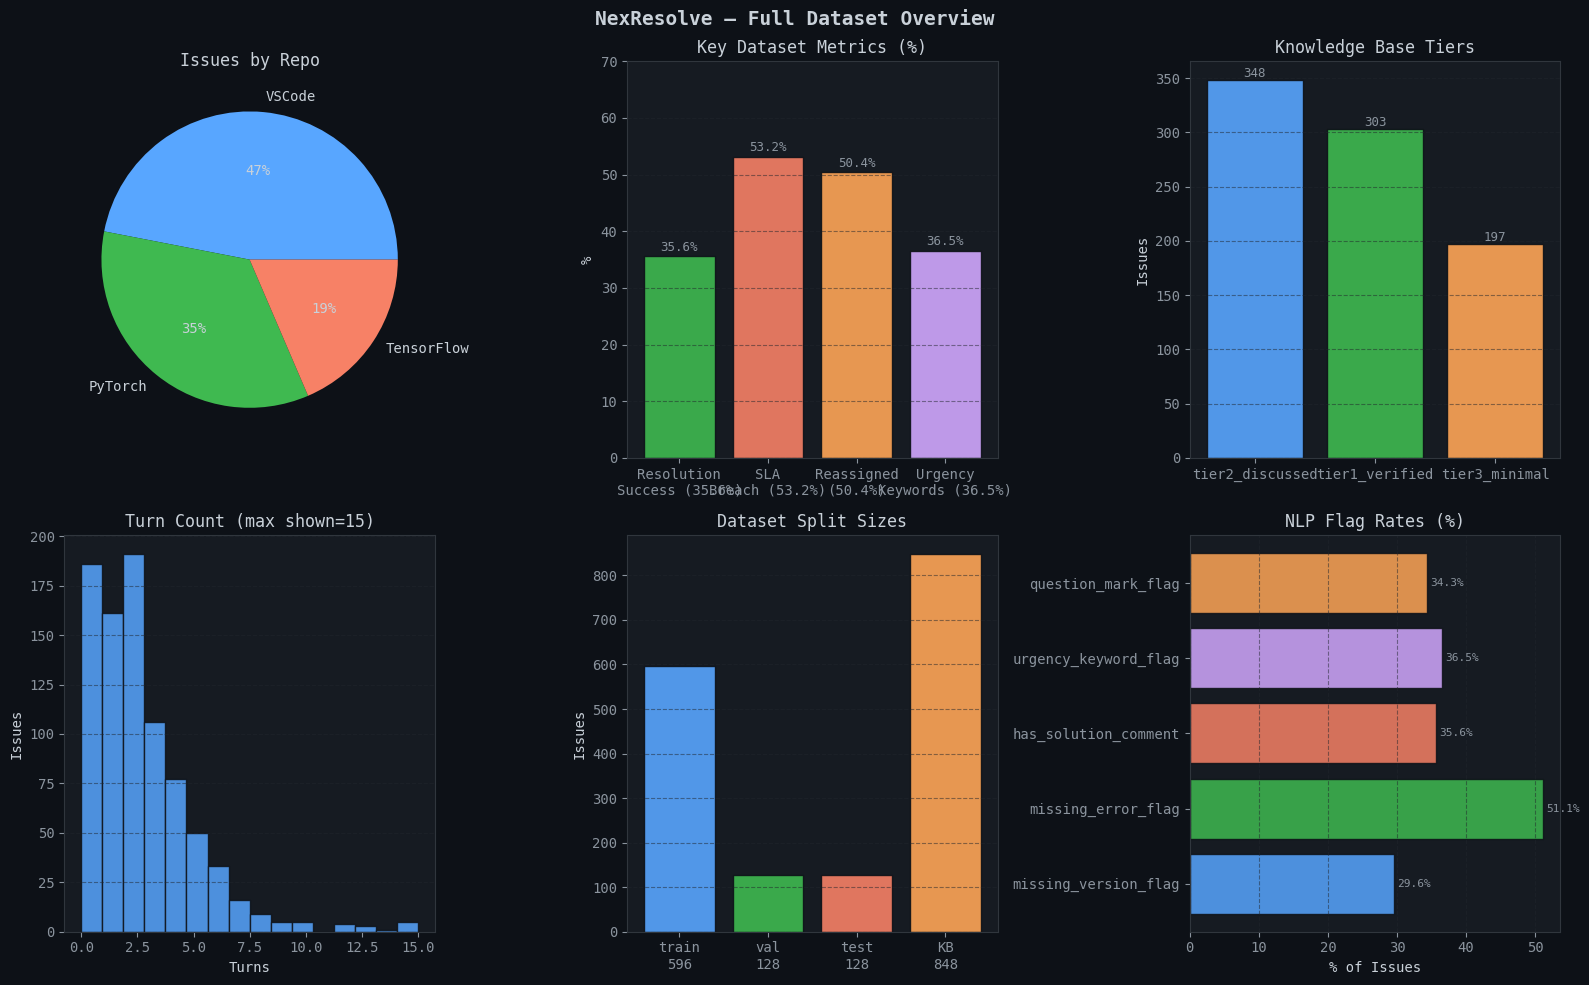

In [31]:
# ── Final combined overview chart ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('NexResolve — Full Dataset Overview', fontweight='bold', fontsize=14)

# 1. Repo distribution
repo = ci['repo'].value_counts()
axes[0,0].pie(repo.values, labels=['VSCode','PyTorch','TensorFlow'],
              colors=COLORS[:3], autopct='%1.0f%%',
              textprops={'color':'#c9d1d9'})
axes[0,0].set_title('Issues by Repo')

# 2. Resolution success vs SLA breach
metrics = ['Resolution\nSuccess (35.6%)', 'SLA\nBreach (53.2%)',
           'Reassigned\n(50.4%)', 'Urgency\nKeywords (36.5%)']
values  = [35.6, 53.2, 50.4, 36.5]
bar_colors = [C2, C3, COLORS[4], C4]
axes[0,1].bar(metrics, values, color=bar_colors, edgecolor='#0d1117', alpha=0.9)
axes[0,1].set_title('Key Dataset Metrics (%)')
axes[0,1].set_ylabel('%')
axes[0,1].set_ylim(0, 70)
axes[0,1].grid(axis='y')
for i, v in enumerate(values):
    axes[0,1].text(i, v+1, f'{v}%', ha='center', fontsize=9, color='#8b949e')

# 3. KB tier
tier = kb['kb_quality_tier'].value_counts()
axes[0,2].bar(tier.index, tier.values, color=[C1, C2, COLORS[4]],
              edgecolor='#0d1117', alpha=0.9)
axes[0,2].set_title('Knowledge Base Tiers')
axes[0,2].set_ylabel('Issues')
axes[0,2].grid(axis='y')
for i, v in enumerate(tier.values):
    axes[0,2].text(i, v+3, str(v), ha='center', fontsize=9, color='#8b949e')

# 4. Turn count
axes[1,0].hist(rl['turn_count'].clip(upper=15), bins=16,
               color=C1, edgecolor='#0d1117', alpha=0.85)
axes[1,0].set_title(f'Turn Count (max shown=15)')
axes[1,0].set_xlabel('Turns')
axes[1,0].set_ylabel('Issues')
axes[1,0].grid(axis='y')

# 5. Split sizes
splits = ['train\n596', 'val\n128', 'test\n128', 'KB\n848']
sizes  = [596, 128, 128, 848]
axes[1,1].bar(splits, sizes, color=[C1, C2, C3, COLORS[4]],
              edgecolor='#0d1117', alpha=0.9)
axes[1,1].set_title('Dataset Split Sizes')
axes[1,1].set_ylabel('Issues')
axes[1,1].grid(axis='y')

# 6. Flag heatmap
flag_data = ci[['missing_version_flag','missing_error_flag','has_solution_comment',
                 'urgency_keyword_flag','question_mark_flag']].mean() * 100
axes[1,2].barh(flag_data.index, flag_data.values, color=COLORS[:5],
               edgecolor='#0d1117', alpha=0.85)
axes[1,2].set_title('NLP Flag Rates (%)')
axes[1,2].set_xlabel('% of Issues')
axes[1,2].grid(axis='x')
for i, v in enumerate(flag_data.values):
    axes[1,2].text(v+0.5, i, f'{v:.1f}%', va='center', fontsize=8, color='#8b949e')

plt.tight_layout()
plt.show()